# Santander

## Importar librerías

In [94]:
import yfinance as yf
import pandas as pd
import numpy as np
import math
import os
import json
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import Input, Concatenate


## Visionado de datos

In [95]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/santander_enriched.csv")
df.head()

,Date,Unnamed: 0,SAN_Adj_Close,SAN_Close,SAN_Volume,SAN_High,SAN_Low,SAN_Open,BBVA_Price,IBEX,...,vix.1,vix.2,vix.3,vix.4,vix.5,bce_hike_strict,hicp_es_yoy,hicp_es_gap_ecb,year,gdp_growth_y
0,2003-12-01,0,2.415460,7.746234,42034006,7.772199,7.538513,7.746234,9.895663,7372.299805,...,16.770000,17.030001,16.170000,16.740000,0,NaN,NaN,NaN,2003,2.93929
1,2003-12-02,1,2.404665,7.711614,187525101,7.763544,7.633719,7.711614,9.857233,7348.700195,...,16.270000,16.889999,16.170000,16.889999,0,NaN,NaN,NaN,2003,2.93929
2,2003-12-03,2,2.420857,7.763544,31459710,7.763544,7.651029,7.763544,9.924485,7384.299805,...,16.629999,16.680000,15.770000,16.080000,0,NaN,NaN,NaN,2003,2.93929
3,2003-12-04,3,2.410062,7.728924,37904447,7.746234,7.668339,7.728924,9.953307,7367.100098,...,16.299999,16.830000,16.290001,16.480000,0,NaN,NaN,NaN,2003,2.93929
4,2003-12-05,4,2.401965,7.702959,20656590,7.728924,7.651029,7.702959,9.857233,7348.100098,...,17.090000,17.320000,16.500000,16.760000,0,NaN,NaN,NaN,2003,2.93929


🔹 Correlación de las features con SAN_Close:

SAN_Close               1.000000
SAN_Low                 0.999559
SAN_High                0.999557
SAN_Open                0.999088
BBVA_Price              0.900517
IBEX                    0.725916
EURUSD                  0.693033
SAN_Adj_Close           0.463071
OIL                     0.182974
house_price_index_es    0.142793
SAN_Volume              0.115335
gdp_growth_y            0.097121
ecb_refi_rate           0.056282
hicp_es_yoy             0.054295
hicp_es_gap_ecb         0.054295
ecb_refi_rate_diff     -0.036641
bce_hike               -0.040044
vix.3                  -0.123635
vix.1                  -0.126686
vix                    -0.126686
vix.4                  -0.131616
vix.2                  -0.141458
eventos_negativos      -0.332917
SP500                  -0.540704
bce_hike_strict        -0.541104
hicp_es                -0.684008
Unnamed: 0             -0.753514
year                   -0.753826
gdp_growth_x                 N

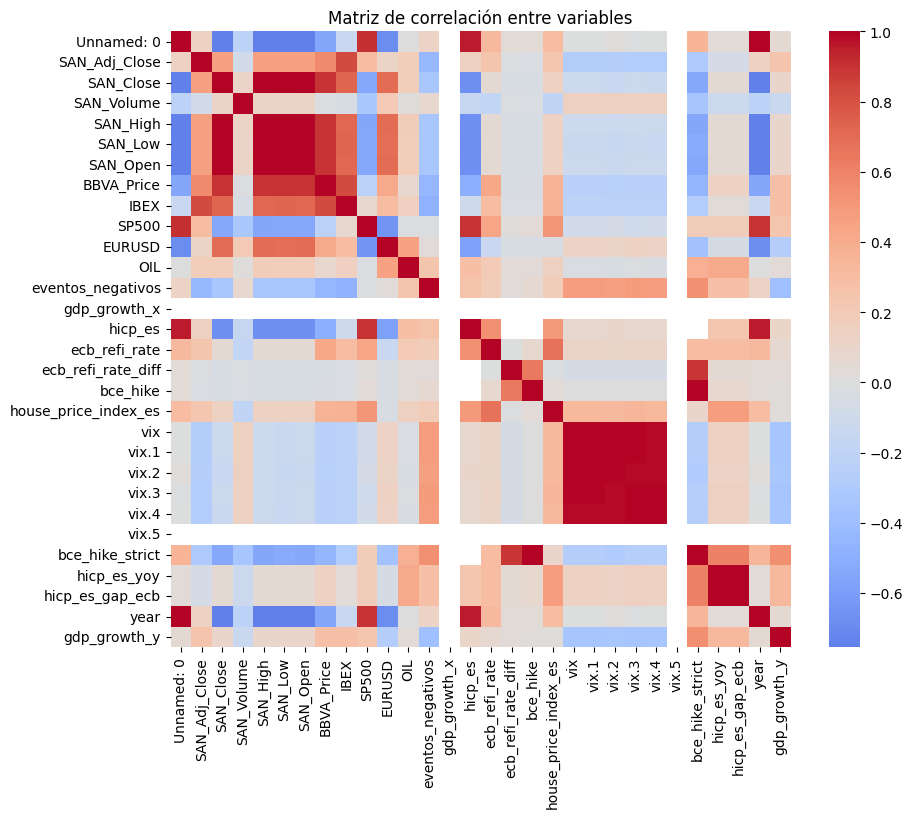

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11504\2153288236.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cor_target.values, y=cor_target.index, palette="viridis")


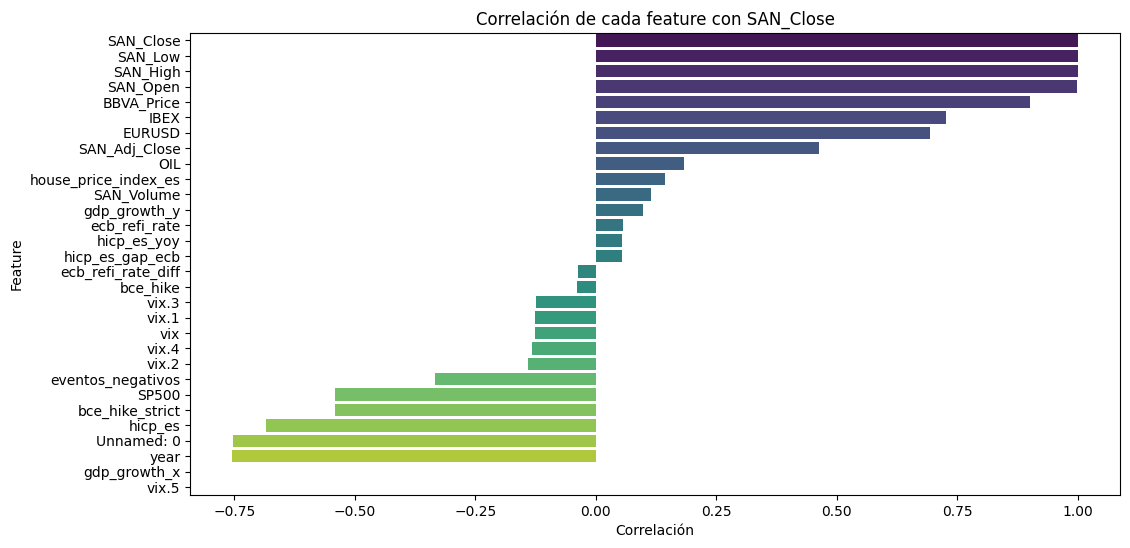

In [96]:
# --- 1️⃣ Calcular matriz de correlación ---
corr = df.corr(numeric_only=True)

# --- 2️⃣ Mostrar correlación de las features con la variable objetivo ---
target_col = "SAN_Close"
cor_target = corr[target_col].sort_values(ascending=False)

print("🔹 Correlación de las features con SAN_Close:\n")
print(cor_target)

# --- 3️⃣ (Opcional) Visualización de la matriz completa ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables")
plt.show()

# --- 4️⃣ (Opcional) Visualizar solo correlaciones con SAN_Close ---
plt.figure(figsize=(12, 6))
sns.barplot(x=cor_target.values, y=cor_target.index, palette="viridis")
plt.title("Correlación de cada feature con SAN_Close")
plt.xlabel("Correlación")
plt.ylabel("Feature")
plt.show()

In [97]:
df.head(10)

,Date,Unnamed: 0,SAN_Adj_Close,SAN_Close,SAN_Volume,SAN_High,SAN_Low,SAN_Open,BBVA_Price,IBEX,...,vix.1,vix.2,vix.3,vix.4,vix.5,bce_hike_strict,hicp_es_yoy,hicp_es_gap_ecb,year,gdp_growth_y
0,2003-12-01,0,2.415460,7.746234,42034006,7.772199,7.538513,7.746234,9.895663,7372.299805,...,16.770000,17.030001,16.170000,16.740000,0,NaN,NaN,NaN,2003,2.93929
1,2003-12-02,1,2.404665,7.711614,187525101,7.763544,7.633719,7.711614,9.857233,7348.700195,...,16.270000,16.889999,16.170000,16.889999,0,NaN,NaN,NaN,2003,2.93929
2,2003-12-03,2,2.420857,7.763544,31459710,7.763544,7.651029,7.763544,9.924485,7384.299805,...,16.629999,16.680000,15.770000,16.080000,0,NaN,NaN,NaN,2003,2.93929
3,2003-12-04,3,2.410062,7.728924,37904447,7.746234,7.668339,7.728924,9.953307,7367.100098,...,16.299999,16.830000,16.290001,16.480000,0,NaN,NaN,NaN,2003,2.93929
4,2003-12-05,4,2.401965,7.702959,20656590,7.728924,7.651029,7.702959,9.857233,7348.100098,...,17.090000,17.320000,16.500000,16.760000,0,NaN,NaN,NaN,2003,2.93929
5,2003-12-09,5,2.393869,7.676994,45362589,7.746234,7.651029,7.676994,9.857233,7391.000000,...,17.629999,17.799999,16.559999,16.629999,0,NaN,NaN,NaN,2003,2.93929
6,2003-12-10,6,2.374977,7.616409,36768915,7.668339,7.538513,7.616409,9.799588,7358.799805,...,17.870001,18.270000,17.580000,17.660000,0,NaN,NaN,NaN,2003,2.93929
7,2003-12-11,7,2.404665,7.711614,35375690,7.711614,7.555823,7.711614,9.905270,7432.200195,...,16.730000,17.950001,16.510000,17.950001,0,NaN,NaN,NaN,2003,2.93929
8,2003-12-12,8,2.404665,7.711614,30422674,7.763544,7.651029,7.711614,9.876448,7434.399902,...,16.410000,16.980000,16.090000,16.190001,0,NaN,NaN,NaN,2003,2.93929
9,2003-12-15,9,2.412760,7.737579,35197966,7.824129,7.728924,7.737579,9.914878,7471.799805,...,17.230000,17.420000,15.790000,15.800000,0,NaN,NaN,NaN,2003,2.93929


In [98]:
# 1) cargar
df = pd.read_csv("../csv/santander_enriched.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# 2) quitar columnas que sobran
cols_to_drop = ["Unnamed: 0", "vix.1", "vix.2", "vix.3", "vix.4", "vix.5"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3) definir grupos de columnas
fin_cols = [
    "SAN_Adj_Close", "SAN_Close", "SAN_Volume", "SAN_High",
    "SAN_Low", "SAN_Open", "BBVA_Price", "IBEX", "SP500", "EURUSD", "OIL"
]
macro_like = [
    "gdp_growth_x", "gdp_growth_y",
    "hicp_es", "hicp_es_yoy", "hicp_es_gap_ecb",
    "ecb_refi_rate", "ecb_refi_rate_diff",
    "bce_hike", "bce_hike_strict",
    "house_price_index_es"
]
bin_like = ["eventos_negativos"]

fin_cols = [c for c in fin_cols if c in df.columns]
macro_like = [c for c in macro_like if c in df.columns]
bin_like = [c for c in bin_like if c in df.columns]

# 4) rellenar financieras
df[fin_cols] = df[fin_cols].interpolate(method="linear", limit_direction="both")

# 5) rellenar macro
df[macro_like] = df[macro_like].ffill().bfill()

# 6) binarias
for c in bin_like:
    df[c] = df[c].fillna(0)

# 7) lo que quede
for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].fillna(0)

print("NaN totales después de rellenar:", df.isna().sum().sum())

# dejamos la fecha como índice
df = df.set_index("Date")


NaN totales después de rellenar: 0


In [99]:
# asumimos que ya tienes estas columnas:
# SAN_Open, SAN_High, SAN_Low, SAN_Close

df["day_range"] = df["SAN_High"] - df["SAN_Low"]
df["close_vs_open"] = df["SAN_Close"] - df["SAN_Open"]

# evitar división por cero
eps = 1e-6
df["close_pos_in_range"] = (df["SAN_Close"] - df["SAN_Low"]) / (
    (df["SAN_High"] - df["SAN_Low"]) + eps
)

# sombras (opcionales)
df["upper_shadow"] = df["SAN_High"] - df[["SAN_Open", "SAN_Close"]].max(axis=1)
df["lower_shadow"] = df[["SAN_Open", "SAN_Close"]].min(axis=1) - df["SAN_Low"]


## Preparación de datos

In [100]:
def preparar_datos_multivariados(df, target_col="SAN_Close", window_size=25):
    df = df.sort_index()

    selected_features = [
    "SAN_Adj_Close",
    "SAN_Open",
    "SAN_High",
    "SAN_Low",
    "SAN_Volume",
    "BBVA_Price",
    "IBEX",
    "SP500",
    "EURUSD",
    "OIL",
    "vix",
    "eventos_negativos",
]


    if "gdp_growth_y" not in df.columns and "gdp_growth_x" in df.columns:
        selected_features.append("gdp_growth_x")

    feature_cols = [c for c in selected_features if c in df.columns]
    features = df[feature_cols].copy()
    target = df[[target_col]].copy()

    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features.iloc[i-window_size:i].values)
        y.append(target.iloc[i].values[0])

    return np.array(X), np.array(y), feature_cols


## PREPROCESAMIENTO

In [101]:
X, y, feature_cols = preparar_datos_multivariados(
    df,
    target_col="SAN_Close",
    window_size=25
)
print(X.shape, y.shape)
print(feature_cols)


(5387, 25, 12) (5387,)
['SAN_Adj_Close', 'SAN_Open', 'SAN_High', 'SAN_Low', 'SAN_Volume', 'BBVA_Price', 'IBEX', 'SP500', 'EURUSD', 'OIL', 'vix', 'eventos_negativos']


## Train y test temporal

In [102]:
# split temporal
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# =============== ESCALADO CORRECTO ===============
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# re-formatear para escalar por feature
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(-1, n_timesteps, n_features)
X_test_scaled  = scaler_X.transform(X_test_2d).reshape(-1, n_timesteps, n_features)

# target
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)


Train: (4309, 25, 12) (4309,)
Test : (1078, 25, 12) (1078,)


## Modelos

In [103]:

def build_rnn(window_size, n_features):
    model = Sequential([
        SimpleRNN(
            64,
            input_shape=(window_size, n_features)
        ),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
    return model

def build_lstm(window_size, n_features):
    model = Sequential([
        LSTM(
            48,
            input_shape=(window_size, n_features),
            return_sequences=True,     # <- para apilar otra
            dropout=0.05,
            recurrent_dropout=0.05
        ),
        LSTM(32, dropout=0.05, recurrent_dropout=0.05),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
    return model

def build_gru(window_size, n_features):
    model = Sequential([
        GRU(
            48,
            input_shape=(window_size, n_features),
            dropout=0.2,
            recurrent_dropout=0.1
        ),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
    return model

def build_lstm_skip(window_size, n_features):
    seq_input = Input(shape=(window_size, n_features))
    x = LSTM(48, return_sequences=True, dropout=0.05, recurrent_dropout=0.05)(seq_input)
    x = LSTM(32, dropout=0.05, recurrent_dropout=0.05)(x)
    x = Dense(32, activation="relu")(x)
    last_step = seq_input[:, -1, :]
    x = Concatenate()([x, last_step])
    out = Dense(1)(x)
    model = Model(seq_input, out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
    return model


## Entrenamiento

In [104]:
# ==============================
# CONFIGURACIÓN BASE
# ==============================
EPOCHS_DEFAULT = 800     # un poco menos
EPOCHS_LSTM = 1000
BATCH = 32
window_size = 25

# Crear carpeta 'modelos' fuera de notebooks si no existe
modelos_dir = os.path.join("..", "modelos")
os.makedirs(modelos_dir, exist_ok=True)

# ==============================
# FUNCIÓN DE ENTRENAMIENTO
# ==============================
def entrenar_modelo(nombre, build_fn, X_train, y_train, X_test, y_test, window_size):
    print(f"\n🧠 Entrenando modelo {nombre}...\n")
    n_features = X_train.shape[2]
    model = build_fn(window_size, n_features)

    model_path = os.path.join(modelos_dir, f"mejor_{nombre.lower()}_santander.h5")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=100 if nombre == "LSTM" else 100,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

    epochs = EPOCHS_LSTM if nombre == "LSTM" else EPOCHS_DEFAULT

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=BATCH,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    # opcional: guardar history para comparar luego
    hist_path = os.path.join(modelos_dir, f"hist_{nombre.lower()}_santander.json")
    with open(hist_path, "w") as f:
        json.dump(history.history, f)

    print(f"✅ Modelo {nombre} finalizado ({len(history.history['loss'])} epochs entrenadas)")
    return model, history

# ==============================
# ENTRENAR LOS TRES MODELOS
# ==============================

rnn_model,  hist_rnn  = entrenar_modelo(
    "RNN",
    build_rnn,
    X_train_scaled, y_train_scaled,   # <--- aquí los scaled
    X_test_scaled,  y_test_scaled,    # <--- aquí también
    window_size
)

lstm_model, hist_lstm = entrenar_modelo(
    "LSTM",
    build_lstm,
    X_train_scaled, y_train_scaled,
    X_test_scaled,  y_test_scaled,
    window_size
)

gru_model,  hist_gru  = entrenar_modelo(
    "GRU",
    build_gru,
    X_train_scaled, y_train_scaled,
    X_test_scaled,  y_test_scaled,
    window_size
)

lstm_skip_model, hist_lstm_skip = entrenar_modelo(
    "LSTM_Skip",
    build_lstm_skip,
    X_train_scaled, y_train_scaled,
    X_test_scaled,  y_test_scaled,
    window_size
)


🧠 Entrenando modelo RNN...

Epoch 1/800


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


117/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0240 
Epoch 1: val_loss improved from None to 0.00122, saving model to ..\modelos\mejor_rnn_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0118 - val_loss: 0.0012
Epoch 2/800
109/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034
Epoch 2: val_loss improved from 0.00122 to 0.00055, saving model to ..\modelos\mejor_rnn_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 5.4941e-04
Epoch 3/800
119/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023
Epoch 3: val_loss improved from 0.00055 to 0.00051, saving model to ..\modelos\mejor_rnn_santander.h5


...

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.3003e-04 - val_loss: 6.4728e-05
Epoch 247/800
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2282e-04
Epoch 247: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.3450e-04 - val_loss: 7.1840e-05
Epoch 248/800
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2957e-04
Epoch 248: val_loss improved from 0.00006 to 0.00006, saving model to ..\modelos\mejor_lstm_skip_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.2650e-04 - val_loss: 6.2604e-05
Epoch 249/800
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4497e-04
Epoch 249: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.3823e-04 - val_loss: 7.0659e-05
Epoch 250/800
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3730e-04
Epoch 250: val_loss improved from 0.00006 to 0.00006, saving model to ..\modelos\mejor_lstm_skip_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.3301e-04 - val_loss: 6.1950e-05
Epoch 251/800
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3483e-04
Epoch 251: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.3366e-04 - val_loss: 6.7120e-05
Epoch 252/800
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2433e-04
Epoch 252: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.3242e-04 - val_loss: 7.5196e-05
Epoch 253/800
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2461e-04
Epoch 253: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.2949e-04 - val_loss: 6.8459e-05
Epoch 254/800
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3373e-04
Epoch 254: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.3621e-04 - val_loss: 8.0946e-05
Epoch 255/800
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3335e-04
Epoch 255

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.3508e-04 - val_loss: 6.1692e-05
Epoch 259/800
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3799e-04
Epoch 259: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.4059e-04 - val_loss: 6.5287e-05
Epoch 260/800
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4523e-04
Epoch 260: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.3654e-04 - val_loss: 6.5489e-05
Epoch 261/800
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2427e-04
Epoch 261: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.2469e-04 - val_loss: 6.8021e-05
Epoch 262/800
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1963e-04
Epoch 262: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.2763e-04 - val_loss: 6.7576e-05
Epoch 263/800
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3395e-04
Epoch 263

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2685e-04 - val_loss: 6.0709e-05
Epoch 268/800
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3966e-04
Epoch 268: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.3280e-04 - val_loss: 6.5900e-05
Epoch 269/800
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2908e-04
Epoch 269: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.2831e-04 - val_loss: 6.6497e-05
Epoch 270/800
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2968e-04
Epoch 270: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.2801e-04 - val_loss: 1.0713e-04
Epoch 271/800
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2180e-04
Epoch 271: val_loss did not improve from 0.00006
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.2479e-04 - val_loss: 9.1179e-05
Epoch 272/800
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2513e-04
Epoch 272

## Predicciones

In [105]:
# predicciones (todavía en escala 0-1 porque el modelo se entrenó así)
y_pred_rnn  = rnn_model.predict(X_test_scaled)
y_pred_lstm = lstm_model.predict(X_test_scaled)
y_pred_gru  = gru_model.predict(X_test_scaled)
y_pred_lstm_skip = lstm_skip_model.predict(X_test_scaled)

# desescalar la y real
y_test_real = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# desescalar las predicciones
pred_rnn_real  = scaler_y.inverse_transform(y_pred_rnn)
pred_lstm_real = scaler_y.inverse_transform(y_pred_lstm)
pred_gru_real  = scaler_y.inverse_transform(y_pred_gru)
pred_lstm_skip_real = scaler_y.inverse_transform(y_pred_lstm_skip)



34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


## Métricas

In [106]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_rnn, rmse_rnn   = evaluar(y_test_real, pred_rnn_real)
mae_lstm, rmse_lstm = evaluar(y_test_real, pred_lstm_real)
mae_gru, rmse_gru   = evaluar(y_test_real, pred_gru_real)
mae_lstm_skip, rmse_lstm_skip = evaluar(y_test_real, pred_lstm_skip_real)

print("RNN  -> MAE:", mae_rnn,  "RMSE:", rmse_rnn)
print("LSTM -> MAE:", mae_lstm, "RMSE:", rmse_lstm)
print("GRU  -> MAE:", mae_gru,  "RMSE:", rmse_gru)
print("LSTM_Skip -> MAE:", mae_lstm_skip, "RMSE:", rmse_lstm_skip)


RNN  -> MAE: 0.0983879694469785 RMSE: 0.13303395184963893
LSTM -> MAE: 0.06845267318838827 RMSE: 0.09315828039351402
GRU  -> MAE: 0.3201901030230832 RMSE: 0.37045846273371225
LSTM_Skip -> MAE: 0.06310641765594484 RMSE: 0.08967301572113362


# Graficar

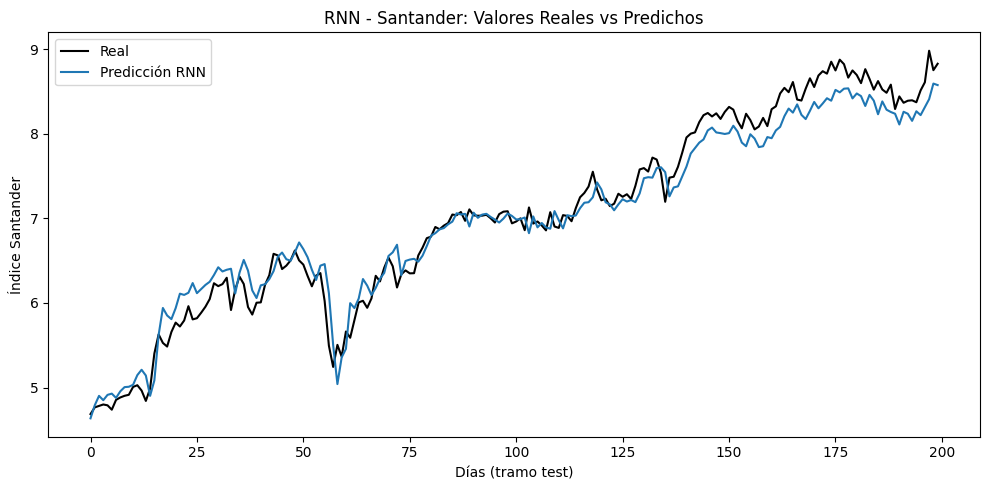

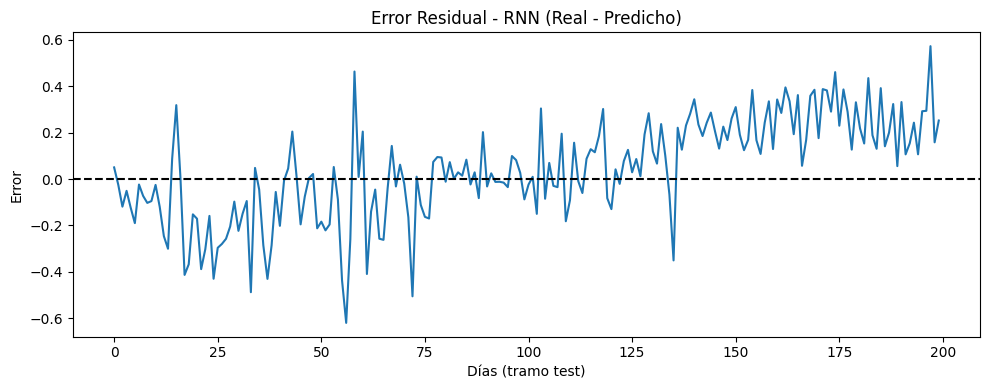

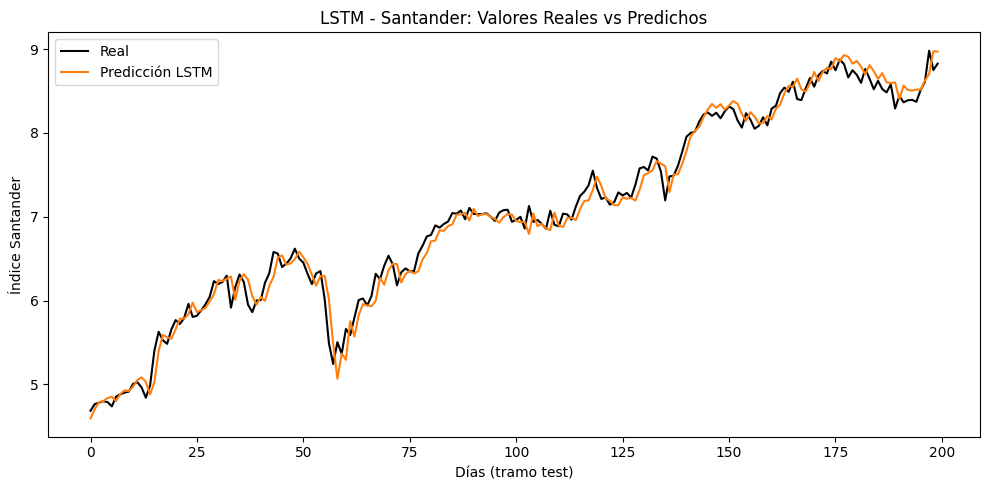

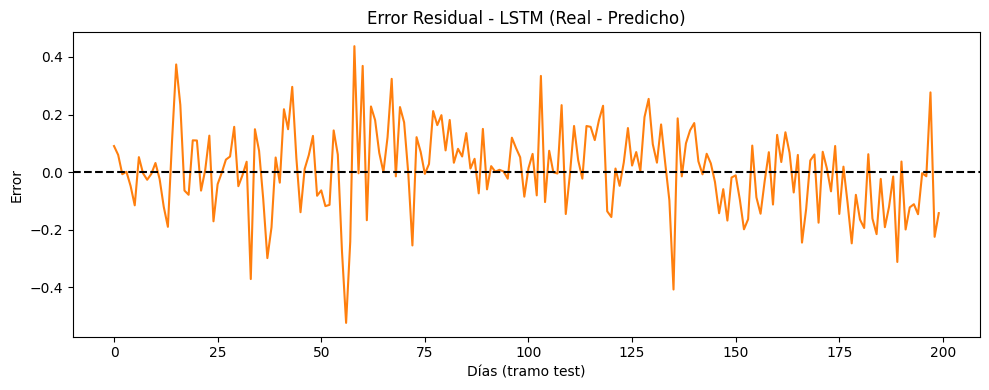

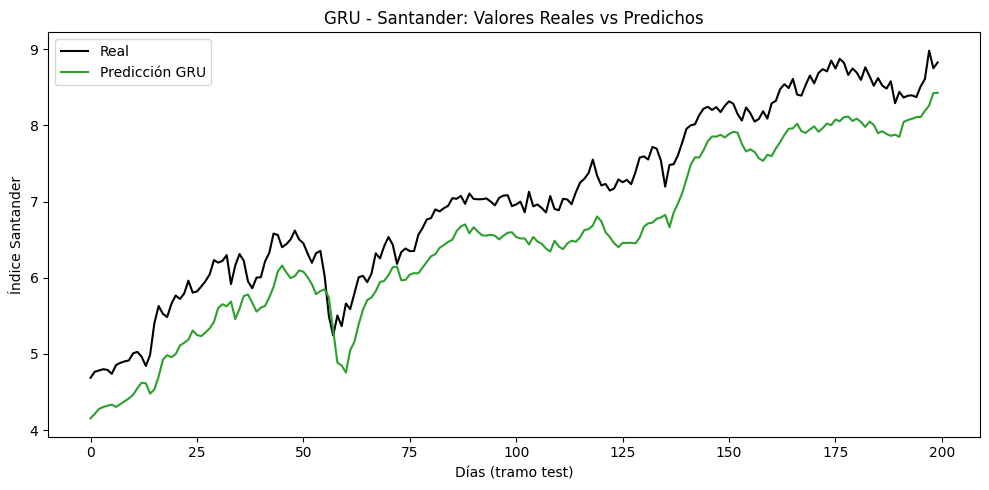

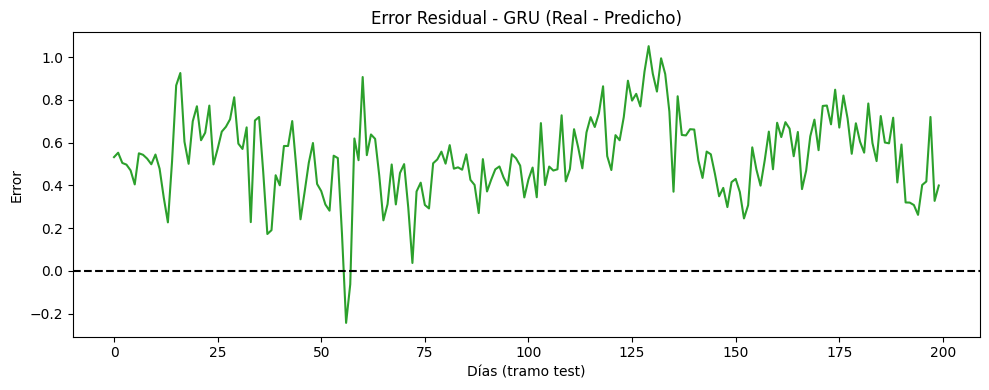

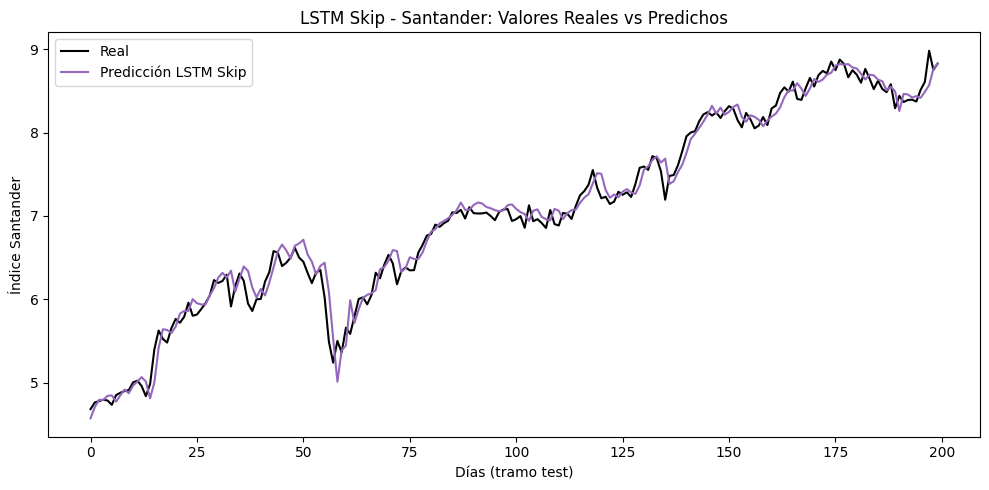

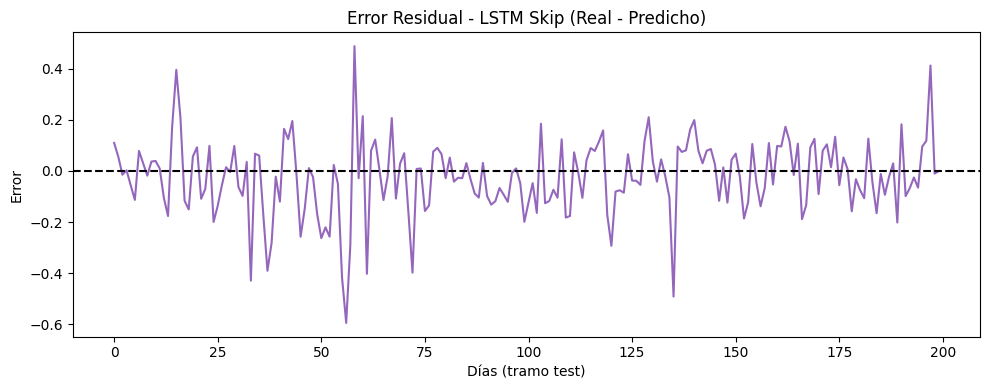

In [107]:
# --- Tramo a mostrar (últimos 200 días del test, por ejemplo) ---
n_mostrar = 200
y_real_plot = y_test_real[-n_mostrar:]
pred_rnn_plot  = pred_rnn_real[-n_mostrar:]
pred_lstm_plot = pred_lstm_real[-n_mostrar:]
pred_gru_plot  = pred_gru_real[-n_mostrar:]
pred_lstm_skip_plot = pred_lstm_skip_real[-n_mostrar:]

# ===============================
# 1️⃣ RNN
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_rnn_plot, label="Predicción RNN", color="tab:blue")
plt.title("RNN - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error RNN ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_rnn_plot, color="tab:blue")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - RNN (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 2️⃣ LSTM
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_lstm_plot, label="Predicción LSTM", color="tab:orange")
plt.title("LSTM - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error LSTM ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_lstm_plot, color="tab:orange")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - LSTM (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 3️⃣ GRU
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_gru_plot, label="Predicción GRU", color="tab:green")
plt.title("GRU - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error GRU ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_gru_plot, color="tab:green")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - GRU (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 4️⃣ LSTM Skip
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_lstm_skip_plot, label="Predicción LSTM Skip", color="tab:purple")
plt.title("LSTM Skip - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()
# --- Error LSTM Skip ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_lstm_skip_plot, color="tab:purple")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - LSTM Skip (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


## Predecir dias futuros

In [108]:
def predecir_siguiente_multivariante(model, df_original, feature_cols, scaler_X, scaler_y, target_col="SAN_Close", window_size=25):
    """
    Predice el siguiente valor del target_col usando LAS MISMAS feature_cols que en el entrenamiento.
    """
    # 1) nos quedamos solo con las columnas que realmente usó el modelo
    features = df_original[feature_cols].copy()

    # 2) tomamos los últimos window_size pasos
    ultimos = features.values[-window_size:]

    # 3) escalar
    ultimos_scaled = scaler_X.transform(ultimos)

    # 4) forma (1, window_size, n_features)
    X_input = ultimos_scaled.reshape((1, window_size, len(feature_cols)))

    # 5) predecir en escala 0-1
    pred_scaled = model.predict(X_input)

    # 6) desescalar
    pred_real = scaler_y.inverse_transform(pred_scaled)

    return pred_real[0, 0]


def predecir_n_dias(model, df_original, feature_cols, scaler_X, scaler_y, n_dias=5, target_col="SAN_Close", window_size=25):
    """
    Hace predicción recursiva n_dias hacia delante.
    Devuelve una lista con las predicciones reales.
    """
    # trabajamos sobre una copia para no tocar el df original
    df_temp = df_original.copy()
    predicciones = []

    for i in range(n_dias):
        siguiente = predecir_siguiente_multivariante(
            model,
            df_temp,
            feature_cols,
            scaler_X,
            scaler_y,
            target_col=target_col,
            window_size=window_size
        )
        predicciones.append(siguiente)

        # añadir ese día “futuro” al df_temp para que el siguiente paso tenga contexto
        # aquí ponemos el target en la columna target, y para el resto de features
        # usamos el último valor (hold) porque no los conocemos en el futuro
        nueva_fila = df_temp.iloc[-1].copy()
        nueva_fila[target_col] = siguiente
        # IMPORTANTÍSIMO: también actualizar las features derivadas si las usas
        df_temp = pd.concat([df_temp, nueva_fila.to_frame().T], ignore_index=True)

    return predicciones


# ====== USO ======
# suponiendo que ya tienes:
# - df (con tus columnas)
# - feature_cols (las que usaste al entrenar)
# - scaler_X, scaler_y
# - lstm_model (o rnn_model, el que quieras)

preds_5 = predecir_n_dias(
    model=lstm_model,
    df_original=df.reset_index(drop=False),   # por si está con Date como índice
    feature_cols=feature_cols,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    n_dias=5,
    target_col="SAN_Close",
    window_size=20   # o 25 según tu modelo
)

print("Predicciones próximos 5 días:")
for i, p in enumerate(preds_5, 1):
    print(f"Día +{i}: {p:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicciones próximos 5 días:
Día +1: 8.9903
Día +2: 8.9984
Día +3: 8.9986
Día +4: 8.9975
Día +5: 8.9952


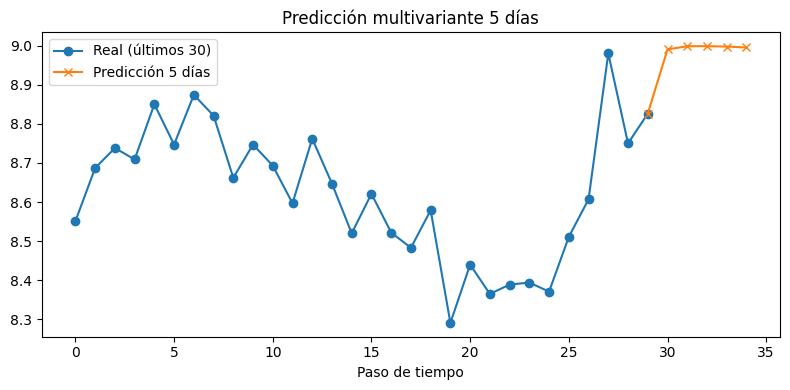

In [109]:
# últimos 30 días reales
ultimos_reales = df["SAN_Close"].tail(30).values

# concatenar para graficar
serie_completa = np.concatenate([ultimos_reales, np.array(preds_5)])

plt.figure(figsize=(8,4))
plt.plot(range(len(ultimos_reales)), ultimos_reales, label="Real (últimos 30)", marker="o")
plt.plot(range(len(ultimos_reales)-1, len(serie_completa)), serie_completa[len(ultimos_reales)-1:],
         label="Predicción 5 días", marker="x")
plt.legend()
plt.title("Predicción multivariante 5 días")
plt.xlabel("Paso de tiempo")
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[np.float32(8.990346), np.float32(8.998745), np.float32(8.994887), np.float32(8.984717), np.float32(8.9804325)]


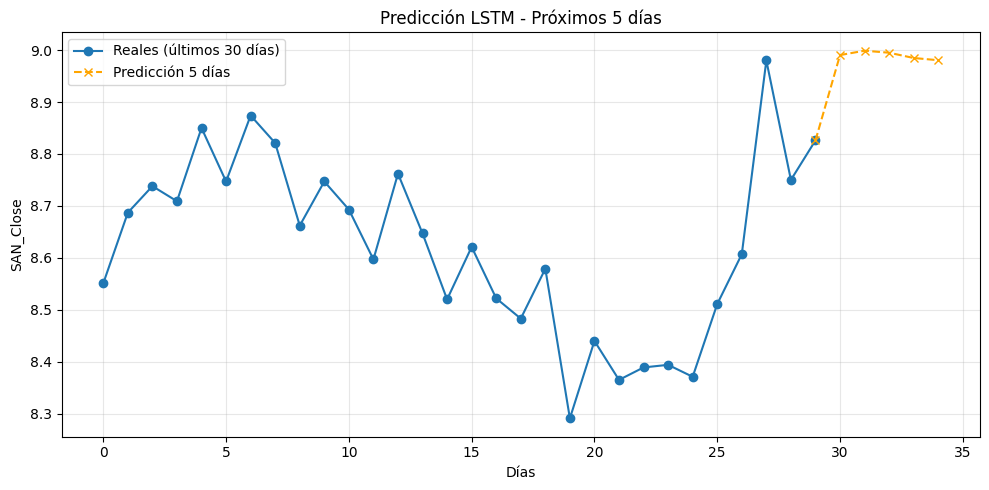

In [110]:
def generar_siguiente_fila(df, feature_cols, target_col="SAN_Close"):
    """
    Genera una fila futura 'realista' a partir de las dos últimas filas.
    Usa reglas sencillas según el tipo de variable.
    """
    last = df.iloc[-1].copy()
    prev = df.iloc[-2].copy()

    nueva = last.copy()

    for col in feature_cols:
        if col not in df.columns:
            continue

        # 1) series de mercado rápidas
        if col in [
            "SAN_Adj_Close", "SAN_Open", "SAN_High", "SAN_Low", "SAN_Volume",
            "BBVA_Price", "IBEX", "SP500", "EURUSD", "OIL", "vix"
        ]:
            # último cambio
            delta = last[col] - prev[col]
            # proyectar el cambio
            nueva[col] = last[col] + delta
            # opcional: limitar cambios exagerados
            if col != "SAN_Volume":
                max_jump = abs(last[col]) * 0.02  # 2% de salto máx
                delta = np.clip(delta, -max_jump, max_jump)
                nueva[col] = last[col] + delta

        # 2) eventos binarios: los dejamos en 0
        elif col in ["eventos_negativos", "bce_hike", "bce_hike_strict"]:
            nueva[col] = 0

        # 3) macro / muy lentas: mantener
        else:
            nueva[col] = last[col]

    # el target lo rellenaremos después con la predicción
    # aquí lo dejamos igual que el último
    nueva[target_col] = last[target_col]

    return nueva


def predecir_siguiente_multivariante(model, df_original, feature_cols, scaler_X, scaler_y, target_col="SAN_Close", window_size=25):
    # usamos solo las columnas del modelo
    features = df_original[feature_cols].copy()
    ultimos = features.values[-window_size:]
    ultimos_scaled = scaler_X.transform(ultimos)
    X_input = ultimos_scaled.reshape((1, window_size, len(feature_cols)))
    pred_scaled = model.predict(X_input)
    pred_real = scaler_y.inverse_transform(pred_scaled)
    return pred_real[0, 0]


def predecir_n_dias_realista(model, df_original, feature_cols, scaler_X, scaler_y,
                             n_dias=5, target_col="SAN_Close", window_size=25):
    """
    Predicción recursiva de n días, pero generando también features futuras de forma razonable.
    """
    df_temp = df_original.copy()
    preds = []

    for _ in range(n_dias):
        # 1) predecir el target del siguiente día con el modelo
        siguiente_valor = predecir_siguiente_multivariante(
            model, df_temp, feature_cols, scaler_X, scaler_y,
            target_col=target_col, window_size=window_size
        )
        preds.append(siguiente_valor)

        # 2) generar una fila futura de features
        nueva_fila = generar_siguiente_fila(df_temp, feature_cols, target_col=target_col)
        # poner el target predicho
        nueva_fila[target_col] = siguiente_valor

        # 3) añadirla al df temporal
        df_temp = pd.concat([df_temp, nueva_fila.to_frame().T], ignore_index=True)

    return preds


# ===== ejemplo de uso =====
preds_5 = predecir_n_dias_realista(
    model=lstm_model,
    df_original=df.reset_index(drop=False),  # si Date era índice
    feature_cols=feature_cols,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    n_dias=5,
    target_col="SAN_Close",
    window_size=20
)
print(preds_5)


# ==============================
# GRÁFICA: últimos días + predicción
# ==============================

def plot_prediccion_multivariante(df, preds, target_col="SAN_Close", ultimos=30, titulo="Predicción multivariante próximos días"):
    """
    Muestra la evolución de los últimos 'ultimos' días reales del target y los próximos valores predichos.
    """
    # Últimos valores reales
    ultimos_reales = df[target_col].tail(ultimos).values

    # Concatenar con las predicciones futuras
    serie_completa = np.concatenate([ultimos_reales, np.array(preds)])

    # Crear eje X
    x_reales = np.arange(len(ultimos_reales))
    x_pred = np.arange(len(ultimos_reales) - 1, len(serie_completa))

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x_reales, ultimos_reales, label=f"Reales (últimos {ultimos} días)", marker="o")
    plt.plot(x_pred, serie_completa[len(ultimos_reales)-1:], label=f"Predicción {len(preds)} días", marker="x", linestyle="--", color="orange")

    # Estética
    plt.title(titulo)
    plt.xlabel("Días")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ====== Ejemplo de uso ======
plot_prediccion_multivariante(
    df=df,
    preds=preds_5,
    target_col="SAN_Close",
    ultimos=30,
    titulo="Predicción LSTM - Próximos 5 días"
)

In [111]:
def predecir_siguiente_multivariante(model, df_original, feature_cols, scaler_X, scaler_y, target_col="SAN_Close", window_size=25):
    """
    Predice el siguiente valor del target_col usando LAS MISMAS feature_cols que en el entrenamiento.
    """
    # 1) nos quedamos solo con las columnas que realmente usó el modelo
    features = df_original[feature_cols].copy()

    # 2) tomamos los últimos window_size pasos
    ultimos = features.values[-window_size:]

    # 3) escalar
    ultimos_scaled = scaler_X.transform(ultimos)

    # 4) forma (1, window_size, n_features)
    X_input = ultimos_scaled.reshape((1, window_size, len(feature_cols)))

    # 5) predecir en escala 0-1
    pred_scaled = model.predict(X_input)

    # 6) desescalar
    pred_real = scaler_y.inverse_transform(pred_scaled)

    return pred_real[0, 0]


def predecir_n_dias(model, df_original, feature_cols, scaler_X, scaler_y, n_dias=5, target_col="SAN_Close", window_size=25):
    """
    Hace predicción recursiva n_dias hacia delante.
    Devuelve una lista con las predicciones reales.
    """
    # trabajamos sobre una copia para no tocar el df original
    df_temp = df_original.copy()
    predicciones = []

    for i in range(n_dias):
        siguiente = predecir_siguiente_multivariante(
            model,
            df_temp,
            feature_cols,
            scaler_X,
            scaler_y,
            target_col=target_col,
            window_size=window_size
        )
        predicciones.append(siguiente)

        # añadir ese día “futuro” al df_temp para que el siguiente paso tenga contexto
        # aquí ponemos el target en la columna target, y para el resto de features
        # usamos el último valor (hold) porque no los conocemos en el futuro
        nueva_fila = df_temp.iloc[-1].copy()
        nueva_fila[target_col] = siguiente
        # IMPORTANTÍSIMO: también actualizar las features derivadas si las usas
        df_temp = pd.concat([df_temp, nueva_fila.to_frame().T], ignore_index=True)

    return predicciones


# ====== USO ======
# suponiendo que ya tienes:
# - df (con tus columnas)
# - feature_cols (las que usaste al entrenar)
# - scaler_X, scaler_y
# - lstm_skip_model (o rnn_model, el que quieras)

preds_5 = predecir_n_dias(
    model=lstm_skip_model,
    df_original=df.reset_index(drop=False),   # por si está con Date como índice
    feature_cols=feature_cols,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    n_dias=5,
    target_col="SAN_Close",
    window_size=20   # o 25 según tu modelo
)

print("Predicciones próximos 5 días:")
for i, p in enumerate(preds_5, 1):
    print(f"Día +{i}: {p:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicciones próximos 5 días:
Día +1: 8.8034
Día +2: 8.8028
Día +3: 8.8026
Día +4: 8.8023
Día +5: 8.8022


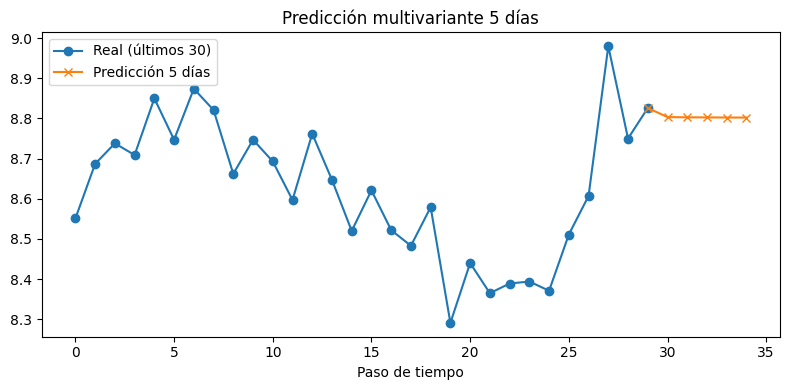

In [112]:
# últimos 30 días reales
ultimos_reales = df["SAN_Close"].tail(30).values

# concatenar para graficar
serie_completa = np.concatenate([ultimos_reales, np.array(preds_5)])

plt.figure(figsize=(8,4))
plt.plot(range(len(ultimos_reales)), ultimos_reales, label="Real (últimos 30)", marker="o")
plt.plot(range(len(ultimos_reales)-1, len(serie_completa)), serie_completa[len(ultimos_reales)-1:],
         label="Predicción 5 días", marker="x")
plt.legend()
plt.title("Predicción multivariante 5 días")
plt.xlabel("Paso de tiempo")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[np.float32(8.803409), np.float32(8.783297), np.float32(8.764405), np.float32(8.745967), np.float32(8.72833)]


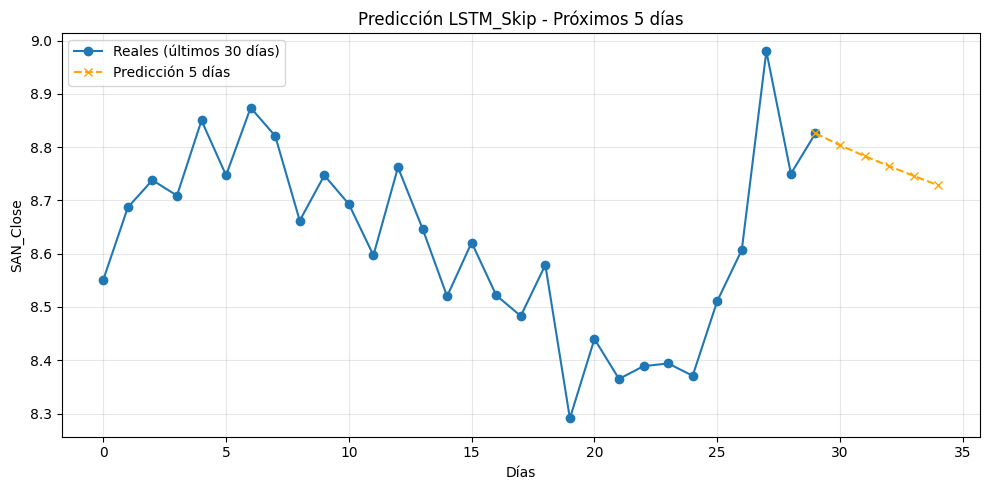

In [113]:
def generar_siguiente_fila(df, feature_cols, target_col="SAN_Close"):
    """
    Genera una fila futura 'realista' a partir de las dos últimas filas.
    Usa reglas sencillas según el tipo de variable.
    """
    last = df.iloc[-1].copy()
    prev = df.iloc[-2].copy()

    nueva = last.copy()

    for col in feature_cols:
        if col not in df.columns:
            continue

        # 1) series de mercado rápidas
        if col in [
            "SAN_Adj_Close", "SAN_Open", "SAN_High", "SAN_Low", "SAN_Volume",
            "BBVA_Price", "IBEX", "SP500", "EURUSD", "OIL", "vix"
        ]:
            # último cambio
            delta = last[col] - prev[col]
            # proyectar el cambio
            nueva[col] = last[col] + delta
            # opcional: limitar cambios exagerados
            if col != "SAN_Volume":
                max_jump = abs(last[col]) * 0.02  # 2% de salto máx
                delta = np.clip(delta, -max_jump, max_jump)
                nueva[col] = last[col] + delta

        # 2) eventos binarios: los dejamos en 0
        elif col in ["eventos_negativos", "bce_hike", "bce_hike_strict"]:
            nueva[col] = 0

        # 3) macro / muy lentas: mantener
        else:
            nueva[col] = last[col]

    # el target lo rellenaremos después con la predicción
    # aquí lo dejamos igual que el último
    nueva[target_col] = last[target_col]

    return nueva


def predecir_siguiente_multivariante(model, df_original, feature_cols, scaler_X, scaler_y, target_col="SAN_Close", window_size=25):
    # usamos solo las columnas del modelo
    features = df_original[feature_cols].copy()
    ultimos = features.values[-window_size:]
    ultimos_scaled = scaler_X.transform(ultimos)
    X_input = ultimos_scaled.reshape((1, window_size, len(feature_cols)))
    pred_scaled = model.predict(X_input)
    pred_real = scaler_y.inverse_transform(pred_scaled)
    return pred_real[0, 0]


def predecir_n_dias_realista(model, df_original, feature_cols, scaler_X, scaler_y,
                             n_dias=5, target_col="SAN_Close", window_size=25):
    """
    Predicción recursiva de n días, pero generando también features futuras de forma razonable.
    """
    df_temp = df_original.copy()
    preds = []

    for _ in range(n_dias):
        # 1) predecir el target del siguiente día con el modelo
        siguiente_valor = predecir_siguiente_multivariante(
            model, df_temp, feature_cols, scaler_X, scaler_y,
            target_col=target_col, window_size=window_size
        )
        preds.append(siguiente_valor)

        # 2) generar una fila futura de features
        nueva_fila = generar_siguiente_fila(df_temp, feature_cols, target_col=target_col)
        # poner el target predicho
        nueva_fila[target_col] = siguiente_valor

        # 3) añadirla al df temporal
        df_temp = pd.concat([df_temp, nueva_fila.to_frame().T], ignore_index=True)

    return preds


# ===== ejemplo de uso =====
preds_5 = predecir_n_dias_realista(
    model=lstm_skip_model,
    df_original=df.reset_index(drop=False),  # si Date era índice
    feature_cols=feature_cols,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    n_dias=5,
    target_col="SAN_Close",
    window_size=20
)
print(preds_5)


# ==============================
# GRÁFICA: últimos días + predicción
# ==============================

def plot_prediccion_multivariante(df, preds, target_col="SAN_Close", ultimos=30, titulo="Predicción multivariante próximos días"):
    """
    Muestra la evolución de los últimos 'ultimos' días reales del target y los próximos valores predichos.
    """
    # Últimos valores reales
    ultimos_reales = df[target_col].tail(ultimos).values

    # Concatenar con las predicciones futuras
    serie_completa = np.concatenate([ultimos_reales, np.array(preds)])

    # Crear eje X
    x_reales = np.arange(len(ultimos_reales))
    x_pred = np.arange(len(ultimos_reales) - 1, len(serie_completa))

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x_reales, ultimos_reales, label=f"Reales (últimos {ultimos} días)", marker="o")
    plt.plot(x_pred, serie_completa[len(ultimos_reales)-1:], label=f"Predicción {len(preds)} días", marker="x", linestyle="--", color="orange")

    # Estética
    plt.title(titulo)
    plt.xlabel("Días")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ====== Ejemplo de uso ======
plot_prediccion_multivariante(
    df=df,
    preds=preds_5,
    target_col="SAN_Close",
    ultimos=30,
    titulo="Predicción LSTM_Skip - Próximos 5 días"
)